In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
import matplotlib.dates as mdates
import numpy as np

# TEMPO

Os gráficos deste capítulo mostram mudanças ao longo do tempo. É muito provável que seus leitores estejam familiarizados com recursos visuais como gráficos de linhas, de áreas e de áreas empilhadas. No entanto, outros tipos — como gráficos de dispersão conectados e gráficos cíclicos — podem exigir mais legendas e anotações para que o leitor consiga interpretá-los adequadamente.

Muitas das representações visuais deste capítulo são variações de gráficos de linhas ou de áreas. Algumas permitem incluir mais dados na página do que o habitual, enquanto outras possibilitam combinar variações ao longo do tempo com outras formas de visualizar os dados. Com gráficos de horizonte (*horizon charts*) e *streamgraphs*, por exemplo, é possível incluir mais dados em uma única visualização, mas eles provavelmente não são os mais adequados para comparações detalhadas. Outros tipos de gráficos, como fluxogramas e linhas do tempo, podem utilizar dados qualitativos ou textos narrativos e elementos visuais para orientar o leitor.

Os gráficos deste capítulo seguem as diretrizes de estilo publicadas pelo Urban Institute, uma instituição de pesquisa sem fins lucrativos sediada em Washington, D.C. O guia de estilo do Urban define a paleta de cores e as fontes da instituição, além de fornecer orientações para diferentes tipos de gráfico.

## GRÁFICO DE LINHAS

O gráfico de linhas e o gráfico de barras são, talvez, os tipos de gráfico mais comuns no mundo. O gráfico de linhas é fácil de ler, apresenta informações de forma clara e pode ser facilmente desenhado com papel e caneta. Os valores dos dados são conectados por linhas para mostrar a evolução ao longo de um período contínuo, permitindo acompanhar tendências e padrões.

Este gráfico de linhas mostra a porcentagem do Produto Interno Bruto (PIB) destinada à assistência à saúde nos Estados Unidos ao longo do período de dezesseis anos, de 2000 a 2015.

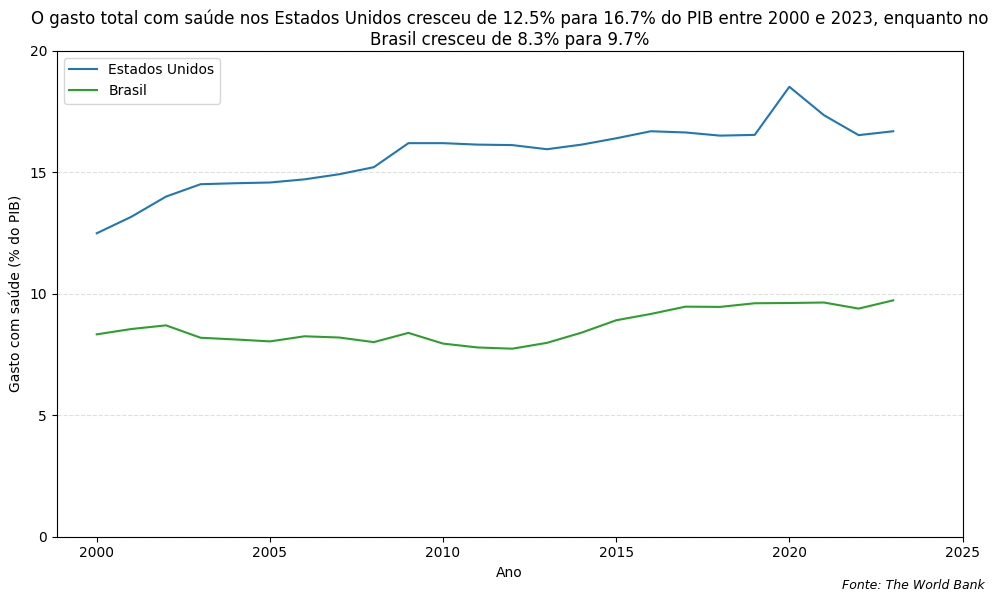

In [2]:
df_pib = pd.read_csv("../Data/gastoSaude_PIB_Brasil_EUA_2000-2025.csv")
df_pib = df_pib.dropna(subset=["valor"])

eua = df_pib[df_pib["pais"] == "Estados Unidos"].sort_values("ano")
brasil = df_pib[df_pib["pais"] == "Brasil"].sort_values("ano")

eua_2000, eua_2023 = eua.loc[eua["ano"] == 2000, "valor"].iloc[0], eua.loc[eua["ano"] == 2023, "valor"].iloc[0]
br_2000, br_2023 = brasil.loc[brasil["ano"] == 2000, "valor"].iloc[0], brasil.loc[brasil["ano"] == 2023, "valor"].iloc[0]

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(eua["ano"], eua["valor"], label="Estados Unidos", color="#1f77b4")
ax.plot(brasil["ano"], brasil["valor"], label="Brasil", color="#2ca02c")

titulo = (
    f"O gasto total com saúde nos Estados Unidos cresceu de {eua_2000:.1f}% para {eua_2023:.1f}% "
    f"do PIB entre 2000 e 2023, enquanto no Brasil cresceu de {br_2000:.1f}% para {br_2023:.1f}%"
)
ax.set_title(titulo, fontsize=12, wrap=True)
ax.set_xlabel("Ano")
ax.set_ylabel("Gasto com saúde (% do PIB)")

ax.set_xticks(np.arange(2000, 2026, 5))
ax.set_yticks(np.arange(0, df_pib["valor"].max() + 5, 5))

ax.legend()
ax.grid(axis="y", linestyle="--", alpha=0.4)

fig.text(0.99, 0.01, "Fonte: The World Bank", ha="right", fontsize=9, style="italic")

plt.tight_layout()
plt.show()


Assim como o gráfico de barras, o gráfico de linhas ocupa uma posição elevada na escala de hierarquia perceptiva. Com linhas referenciadas ao mesmo eixo horizontal, é fácil comparar os valores entre si e entre diferentes séries.

Por mais simples que seja criar e ler um gráfico de linhas, há vários aspectos a serem considerados — alguns de natureza estética e outros de natureza substantiva.

### Não há limite para o número de linhas que você traça.

Não existe uma regra rígida que determine o número de séries que você pode incluir em um único gráfico de linhas. O segredo não é preocupar-se com a quantidade de dados no gráfico, mas sim com o objetivo dele e com a forma de direcionar a atenção do leitor. Por exemplo, em um gráfico de linhas com muitas séries, você pode destacar ou enfatizar um subconjunto dos seus dados.

Suponha que quiséssemos mostrar a participação dos gastos públicos com saúde nos Estados Unidos e na Alemanha, mas também quiséssemos apresentá-los em relação aos outros trinta e quatro países que compõem a Organização para a Cooperação e Desenvolvimento Econômico (OCDE). Para isso, em vez de aplicar a mesma saturação de cor e espessura a todas as linhas, poderíamos destacar com cor e maior espessura apenas as linhas referentes aos Estados Unidos e à Alemanha, deixando as linhas dos outros trinta e dois países em cinza e com traço fino. A estratégia "Comece pelo cinza", apresentada no Capítulo 2, mostra-se útil nessa situação.

Lembre-se da seção sobre processamento pré-atentivo: a cor e a espessura da linha são dois dos atributos pré-atentivos (página 25); portanto, nossa atenção é atraída para as linhas mais espessas e coloridas. A vantagem da estratégia em tons de cinza é que o leitor consegue perceber o padrão geral de toda a amostra e, ao mesmo tempo, concentrar-se nas duas linhas de interesse.

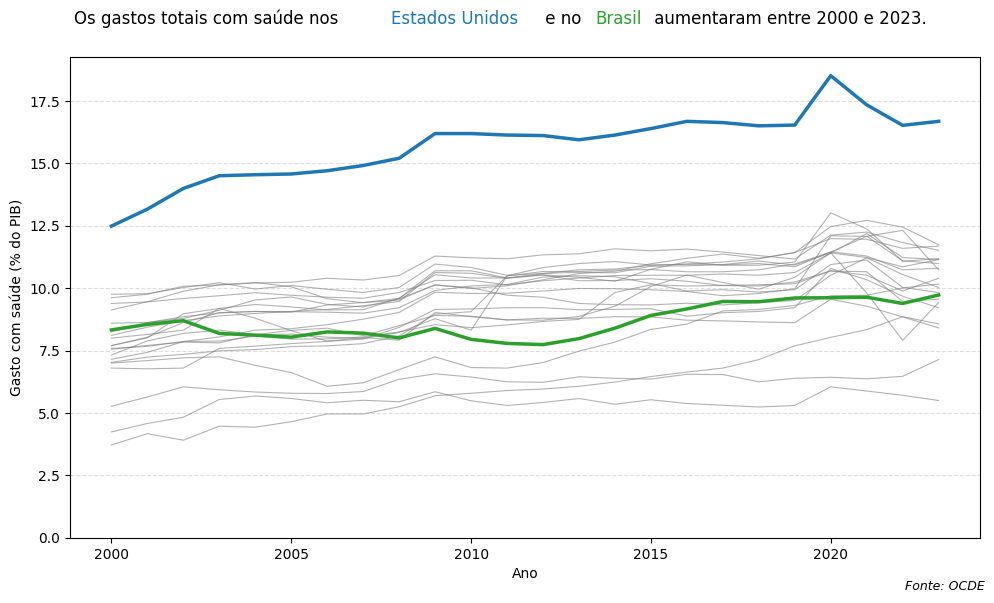

In [3]:
df_ocde = pd.read_csv("../Data/gasto_saude_pct_pib_ocde_2000_2023.csv", encoding="utf-16", sep="\t")
df_ocde = df_ocde.dropna(subset=["valor_pct_pib"])

destaques = ["Brasil", "Estados Unidos"]
cores_destaque = {"Brasil": "#2ca02c", "Estados Unidos": "#1f77b4"}

fig, ax = plt.subplots(figsize=(10, 6))

for pais, grupo in df_ocde.groupby("pais"):
    if pais in destaques:
        continue
    grupo = grupo.sort_values("ano")
    ax.plot(grupo["ano"], grupo["valor_pct_pib"], color="gray", linewidth=0.8, alpha=0.6)

for pais in destaques:
    grupo = df_ocde[df_ocde["pais"] == pais].sort_values("ano")
    ax.plot(grupo["ano"], grupo["valor_pct_pib"], label=pais, color=cores_destaque[pais], linewidth=2.5)


def titulo_colorido(ax, segmentos, y=1.06, fontsize=12):
    # desenha um título com trechos coloridos, centralizado no eixo, usando texto renderizado incrementalmente
    fig = ax.figure
    fig.canvas.draw()
    renderer = fig.canvas.get_renderer()

    larguras = []
    for texto, cor in segmentos:
        t = ax.text(0, 0, texto, fontsize=fontsize, transform=ax.transAxes, alpha=0)
        larguras.append(t.get_window_extent(renderer=renderer).width)
        t.remove()

    largura_eixo = ax.get_window_extent(renderer=renderer).width
    x = 0.5 - (sum(larguras) / largura_eixo) / 2
    for (texto, cor), largura in zip(segmentos, larguras):
        ax.text(x, y, texto, transform=ax.transAxes, fontsize=fontsize, color=cor, va="bottom")
        x += largura / largura_eixo


titulo_colorido(ax, [
    ("Os gastos totais com saúde nos ", "black"),
    ("Estados Unidos", cores_destaque["Estados Unidos"]),
    (" e no ", "black"),
    ("Brasil", cores_destaque["Brasil"]),
    (" aumentaram entre 2000 e 2023.", "black"),
])

ax.set_xlabel("Ano")
ax.set_ylabel("Gasto com saúde (% do PIB)")

ax.set_xticks(np.arange(2000, 2024, 5))
ax.set_ylim(bottom=0)

ax.grid(axis="y", linestyle="--", alpha=0.4)

fig.text(0.99, 0.01, "Fonte: OCDE", ha="right", fontsize=9, style="italic")

plt.tight_layout()
plt.show()


Também podemos pegar o gráfico de linhas e dividi-lo em vários gráficos — a abordagem de "múltiplos pequenos" (*small multiples*). Podemos incluir apenas a linha de interesse em cada gráfico menor ou incluir todas as linhas e utilizar a estratégia de usar tons de cinza. O conjunto de gráficos de linhas em múltiplos pequenos, apresentado na página seguinte, utiliza a primeira abordagem e mostra os gastos com saúde de nove dos trinta e quatro países da OCDE. Em vez de agrupar todas as nove linhas em um único gráfico, cada país possui seu próprio painel. Embora possamos perder um pouco da perspectiva sobre os valores relativos de gastos em cada país, esse layout oferece mais espaço para cada país e, consequentemente, a oportunidade de incluir mais detalhes, rótulos ou outras anotações.

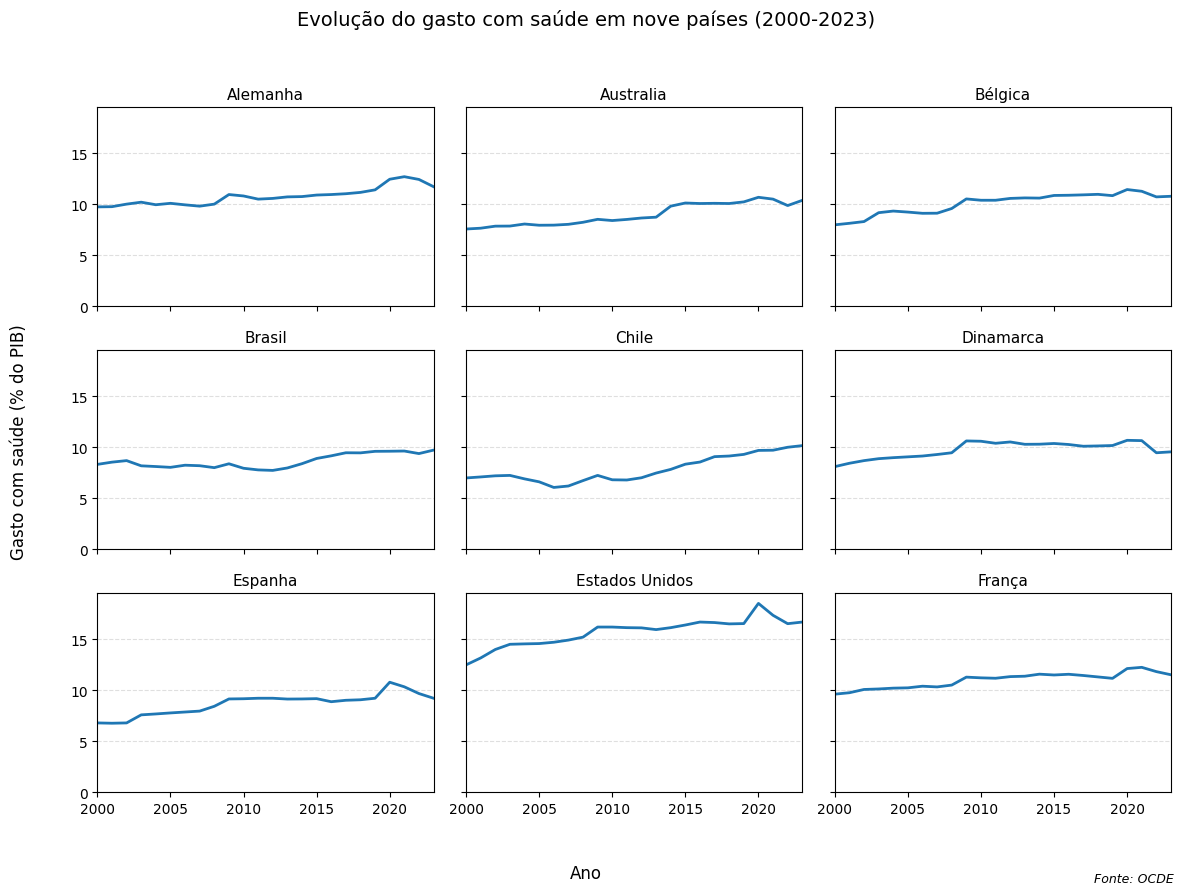

In [4]:
paises = [
    "Alemanha", "Australia", "Belgica", "Brasil", "Chile",
    "Dinamarca", "Espanha", "Estados Unidos", "Franca",
]
rotulos = {"Belgica": "Bélgica", "Franca": "França"}

fig, eixos = plt.subplots(3, 3, figsize=(12, 9), sharex=True, sharey=True)
limite_superior = df_ocde["valor_pct_pib"].max() + 1

for eixo, pais in zip(eixos.flat, paises):
    dados_pais = df_ocde[df_ocde["pais"] == pais].sort_values("ano")
    eixo.plot(dados_pais["ano"], dados_pais["valor_pct_pib"], color="#1f77b4", linewidth=2)
    eixo.set_title(rotulos.get(pais, pais), fontsize=11)
    eixo.set_xlim(2000, 2023)
    eixo.set_ylim(0, limite_superior)
    eixo.set_xticks(np.arange(2000, 2024, 5))
    eixo.grid(axis="y", linestyle="--", alpha=0.4)

fig.supxlabel("Ano")
fig.supylabel("Gasto com saúde (% do PIB)")
fig.suptitle("Evolução do gasto com saúde em nove países (2000-2023)", fontsize=14)
fig.text(0.99, 0.01, "Fonte: OCDE", ha="right", fontsize=9, style="italic")

plt.tight_layout(rect=(0.03, 0.03, 1, 0.95))
plt.show()


### Você não precisa começar o eixo no zero.

Uma das poucas regras práticas da visualização de dados é que os eixos de gráficos de barras devem começar em zero (veja o Capítulo 4). Como percebemos os valores com base no comprimento das barras, iniciar o eixo em um valor diferente de zero superdimensiona as diferenças entre os valores.

Isso não se aplica a gráficos de linhas. O eixo de um gráfico de linhas não precisa necessariamente começar em zero. Assim como ocorre com muitos aspectos da visualização de dados, existem complicações e diferentes perspectivas. Se dizemos que o eixo não precisa começar em zero, qual seria a faixa apropriada? Onde devemos iniciar e encerrar o eixo?

Para ilustrar, vamos examinar mais de perto as variações nos gastos com saúde nos Estados Unidos. Cada um dos quatro gráficos abaixo utiliza uma escala diferente no eixo vertical. Como é possível perceber claramente, essas escalas influenciam nossa percepção tanto do nível quanto da variação dos gastos. No gráfico do canto superior esquerdo, onde o eixo varia de 0 a 20, observamos um leve aumento nos gastos. À medida que avançamos no sentido horário pelos gráficos e a escala do eixo se torna cada vez menor, a variação nos gastos parece cada vez mais 

Não existe uma resposta certa para a escolha do eixo vertical; a resposta depende dos dados e do seu objetivo. Se você precisa demonstrar que a economia sofrerá um revés caso os gastos atinjam 17% do PIB, então o gráfico no canto inferior direito pode ser a melhor opção. Se você estiver apresentando uma análise mais geral, um dos gráficos da linha superior talvez seja preferível, pois eles também mostram claramente o aumento dos gastos ao longo do tempo. Caso precise apresentar uma análise detalhada dos gastos em cada ano, vale a pena considerar os gráficos à direita.drástica.

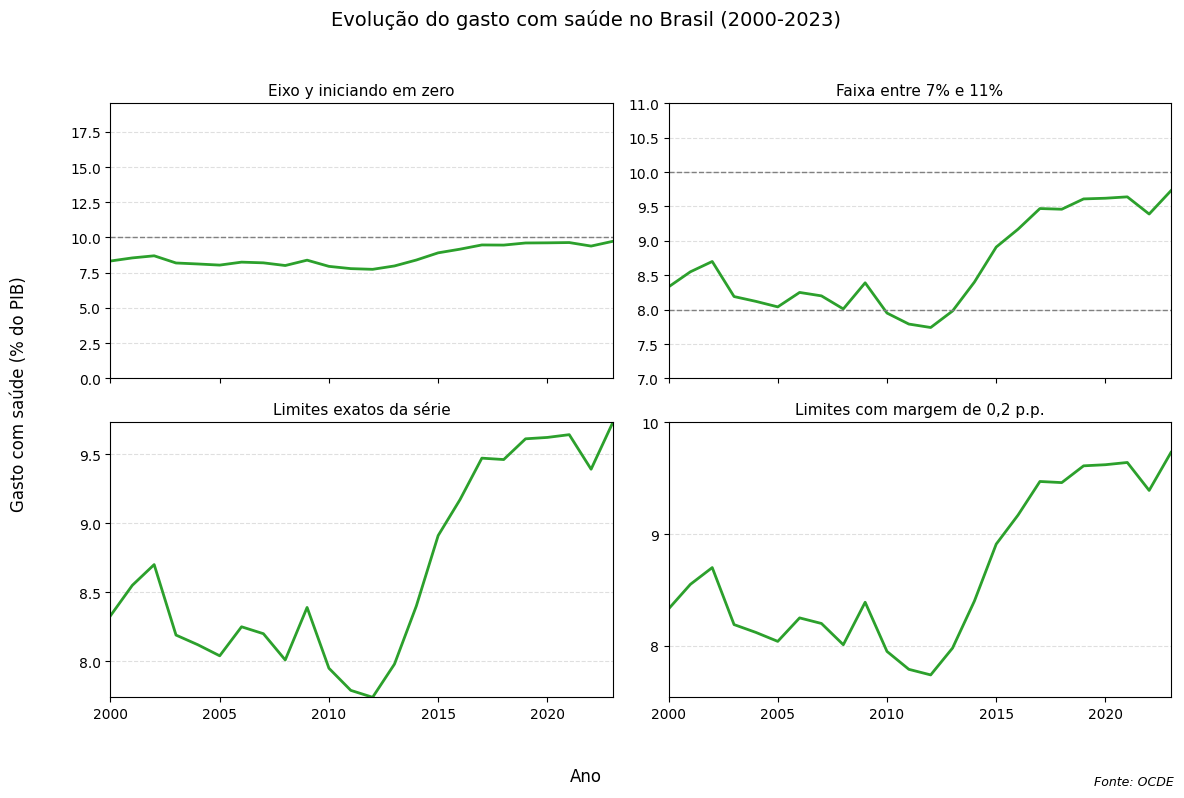

In [5]:
dados_brasil = df_ocde[df_ocde["pais"] == "Brasil"].sort_values("ano")
valor_minimo = dados_brasil["valor_pct_pib"].min()
valor_maximo = dados_brasil["valor_pct_pib"].max()

fig, eixos = plt.subplots(2, 2, figsize=(12, 8), sharex=True)

configuracoes = [
    {
        "eixo": eixos[0, 0],
        "titulo": "Eixo y iniciando em zero",
        "limites": (0, limite_superior),
        "linhas": [10],
        "ticks": None,
    },
    {
        "eixo": eixos[0, 1],
        "titulo": "Faixa entre 7% e 11%",
        "limites": (7, 11),
        "linhas": [8, 10],
        "ticks": None,
    },
    {
        "eixo": eixos[1, 0],
        "titulo": "Limites exatos da série",
        "limites": (valor_minimo, valor_maximo),
        "linhas": [],
        "ticks": [8.0, 8.5, 9.0, 9.5],
    },
    {
        "eixo": eixos[1, 1],
        "titulo": "Limites com margem de 0,2 p.p.",
        "limites": (valor_minimo - 0.2, valor_maximo + 0.2),
        "linhas": [],
        "ticks": [8.0, 9.0, 10.0],
    },
]

for configuracao in configuracoes:
    eixo = configuracao["eixo"]
    limite_inferior, limite_superior_painel = configuracao["limites"]

    eixo.plot(dados_brasil["ano"], dados_brasil["valor_pct_pib"], color="#2ca02c", linewidth=2)
    eixo.set_title(configuracao["titulo"], fontsize=11)
    eixo.set_xlim(2000, 2023)
    eixo.set_ylim(limite_inferior, limite_superior_painel)
    eixo.set_xticks(np.arange(2000, 2024, 5))

    if configuracao["ticks"]:
        eixo.set_yticks(configuracao["ticks"])

    for valor in configuracao["linhas"]:
        eixo.axhline(valor, color="gray", linestyle="--", linewidth=1)

    eixo.grid(axis="y", linestyle="--", alpha=0.4)

fig.supxlabel("Ano")
fig.supylabel("Gasto com saúde (% do PIB)")
fig.suptitle("Evolução do gasto com saúde no Brasil (2000-2023)", fontsize=14)
fig.text(0.99, 0.01, "Fonte: OCDE", ha="right", fontsize=9, style="italic")

plt.tight_layout(rect=(0.03, 0.03, 1, 0.95))
plt.show()


Pessoalmente, tento evitar a abordagem do gráfico inferior esquerdo, onde o eixo não começa em zero e o valor superior ou inferior é igual ao valor mínimo ou máximo dos dados. Nesse caso, o gráfico me parece muito "apertado" e acho que pode sugerir que os dados não podem ir além do que está representado, o que raramente acontece. 

Outra maneira de encarar isso é observar como os dados, o contexto, o conteúdo e as unidades funcionam em conjunto. Uma mudança nos gastos de 12% para 17% do PIB representa uma alteração significativa no contexto da reforma da saúde. Por outro lado, não é tão importante o fato de meus filhos conseguirem me vencer dezessete vezes em um jogo de tabuleiro agora, em vez das doze vezes de quando eram um pouco mais novos — pelo menos para mim, embora para eles isso seja muito importante!

Vale ressaltar também que nossa percepção de onde se situa o zero nesse espaço é afetada pela forma como traçamos o eixo vertical. Sem examinar atentamente um gráfico de linhas, é provável que você presuma que a base do eixo vertical corresponde a zero; em certos casos — especialmente quando as séries de dados incluem valores positivos e negativos —, esse detalhe pode ser de grande importância. Considere estes gráficos que mostram a variação anual, em pontos percentuais, dos gastos com saúde, em vez do nível de gastos como proporção do PIB. No gráfico à esquerda, não fica imediatamente claro que houve redução nos gastos durante esse período, pois a linha de base zero não está bem definida. Basta escurecer um pouco mais essa linha do eixo em relação às demais — como se vê no gráfico à direita — para tornar evidente que, em três anos, os gastos com saúde como parcela do PIB registraram queda em relação ao ano anterior.

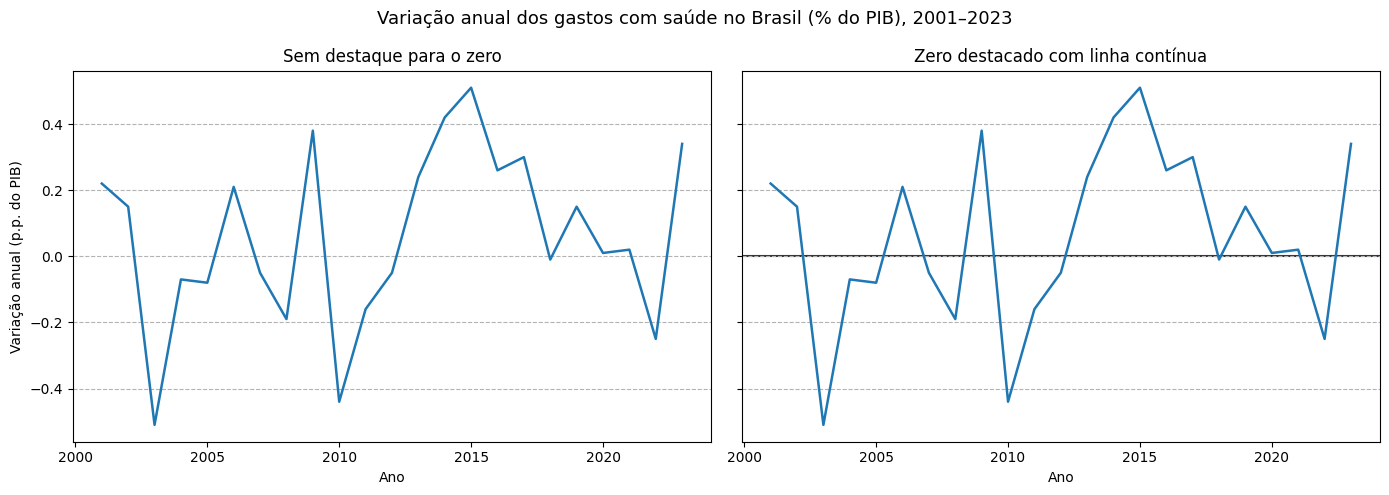

In [6]:
# --- Variação anual do Brasil (em pontos percentuais do PIB) ---
df_br = (
    df_pib.loc[df_pib["pais"] == "Brasil", ["ano", "valor"]]
    .sort_values("ano")
    .assign(variacao=lambda d: d["valor"].diff())
    .dropna(subset=["variacao"])   # descarta o primeiro ano (sem referência anterior)
)

GRID_STEP = 0.2  # espaçamento das linhas de grade no eixo y (p.p.)


def plot_variacao(ax, dados, titulo, destacar_zero=False):
    """Desenha a variação anual em `ax`; opcionalmente destaca a linha y = 0."""
    ax.plot(dados["ano"], dados["variacao"], lw=1.8, ms=5, color="tab:blue")
    ax.set_title(titulo)
    ax.set_xlabel("Ano")
    ax.set_ylabel("Variação anual (p.p. do PIB)")
    ax.yaxis.set_major_locator(MultipleLocator(GRID_STEP))
    ax.grid(axis="y", linestyle="--", linewidth=0.8, color="0.7")
    if destacar_zero:
        ax.axhline(0, color="0.2", linestyle="-", linewidth=1.5, zorder=1)


fig, (ax_esq, ax_dir) = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
plot_variacao(ax_esq, df_br, "Sem destaque para o zero")
plot_variacao(ax_dir, df_br, "Zero destacado com linha contínua", destacar_zero=True)
ax_dir.set_ylabel("")  # eixo compartilhado: rótulo só à esquerda

fig.suptitle("Variação anual dos gastos com saúde no Brasil (% do PIB), 2001–2023", fontsize=13)
fig.tight_layout()
plt.show()

### Cuidado com a ilusão da espessura da linha 

Com gráficos de linhas (e com outros gráficos de séries temporais, aliás), tendemos a estimar incorretamente as diferenças entre duas curvas.

Considere este gráfico de William Playfair, engenheiro e cientista político escocês frequentemente reconhecido como o fundador dos métodos gráficos em estatística. Em seu gráfico de 1785, Playfair representa as exportações e importações (em milhões de libras esterlinas) entre a Inglaterra e as Índias Orientais no período de 1700 a 1780. A linha superior indica as importações, e a linha inferior, as exportações. A distância vertical — ou o intervalo — entre as duas linhas mostra a balança comercial (positiva) da Inglaterra com as Índias Orientais. Começando em 1700, à esquerda, observa-se o crescimento do saldo ao longo dos primeiros trinta anos, aproximadamente. Em seguida, por volta de 1730, esse intervalo começa a diminuir, atingindo seu ponto de menor amplitude por volta de 1755. A balança comercial parece então crescer por algum tempo, expandindo-se rapidamente após 1770.

Você notou a elevação na balança comercial após 1760? No período de três anos entre 1762 e 1764, as importações aumentaram rapidamente enquanto as exportações cresciam mais lentamente, resultando em um saldo comercial maior. Entre 1764 e 1766, as exportações para as Índias Orientais dispararam, fazendo com que o saldo comercial caísse novamente. No entanto, esse pico ocorrido entre 1762 e 1764 é difícil de visualizar no gráfico original de Playfair. Essas variações são muito mais fáceis de observar neste gráfico de linhas, que representa a diferença entre importações e exportações.

É aqui que atua a ilusão da espessura da linha: tendemos a avaliar a distância entre curvas pelo ponto de maior proximidade, em vez de pela distância vertical. Diversos estudiosos demonstraram esse efeito e sugeriram tipos alternativos de gráfico, mas a solução mais simples pode ser plotar a diferença sempre que ela for a métrica de interesse.

### Inclua marcadores de dados para marcar valores específicos.

Os marcadores de dados são exatamente o que o nome sugere: símbolos ao longo da linha que marcam pontos específicos da série. Não existe uma resposta certa sobre quando utilizá-los. Pessoalmente, incluo marcadores de dados quando tenho poucas linhas ou pontos de dados, ou para pontos específicos que desejo rotular ou anotar. Os marcadores de dados conferem mais peso visual ao gráfico.

Estes gráficos, por exemplo, mostram os gastos com saúde como proporção do PIB da Alemanha e da Espanha. Há tão poucos pontos de dados e as variações nas séries são tão sutis que a inclusão de marcadores circulares confere mais peso visual às linhas.

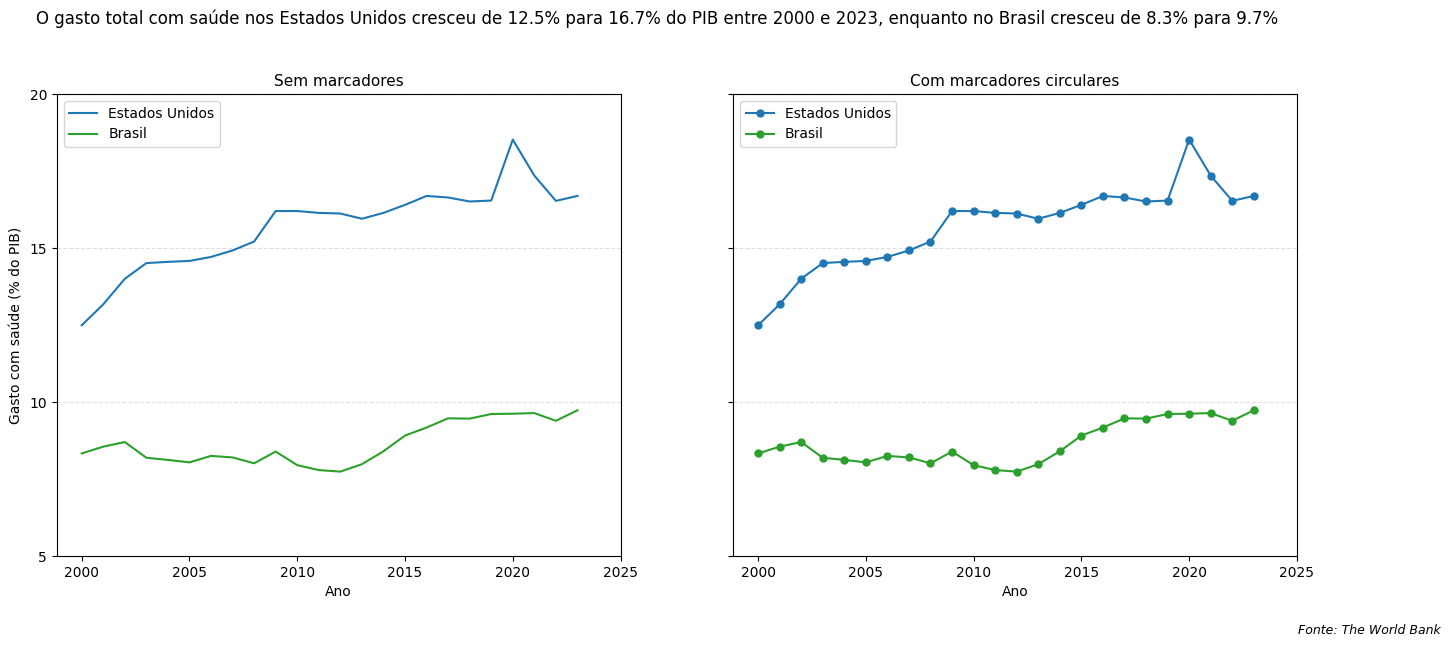

In [7]:
df_pib = pd.read_csv("../Data/gastoSaude_PIB_Brasil_EUA_2000-2025.csv")
df_pib = df_pib.dropna(subset=["valor"])

eua = df_pib[df_pib["pais"] == "Estados Unidos"].sort_values("ano")
brasil = df_pib[df_pib["pais"] == "Brasil"].sort_values("ano")

eua_2000, eua_2023 = eua.loc[eua["ano"] == 2000, "valor"].iloc[0], eua.loc[eua["ano"] == 2023, "valor"].iloc[0]
br_2000, br_2023 = brasil.loc[brasil["ano"] == 2000, "valor"].iloc[0], brasil.loc[brasil["ano"] == 2023, "valor"].iloc[0]

titulo = (
    f"O gasto total com saúde nos Estados Unidos cresceu de {eua_2000:.1f}% para {eua_2023:.1f}% "
    f"do PIB entre 2000 e 2023, enquanto no Brasil cresceu de {br_2000:.1f}% para {br_2023:.1f}%"
)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

# --- Versão original: sem marcadores ---
ax1.plot(eua["ano"], eua["valor"], label="Estados Unidos", color="#1f77b4")
ax1.plot(brasil["ano"], brasil["valor"], label="Brasil", color="#2ca02c")
ax1.set_title("Sem marcadores", fontsize=11)
ax1.set_xlabel("Ano")
ax1.set_ylabel("Gasto com saúde (% do PIB)")
ax1.set_xticks(np.arange(2000, 2026, 5))
# definindo os limites em y para ficar entre 5 e 20, com espaçamento de 5 p.p.
ax1.set_yticks(np.arange(5, 25, 5))
ax1.legend()
ax1.grid(axis="y", linestyle="--", alpha=0.4)

# --- Versão com marcadores circulares ---
ax2.plot(eua["ano"], eua["valor"], label="Estados Unidos", color="#1f77b4",
          marker="o", markersize=5)
ax2.plot(brasil["ano"], brasil["valor"], label="Brasil", color="#2ca02c",
          marker="o", markersize=5)
ax2.set_title("Com marcadores circulares", fontsize=11)
ax2.set_xlabel("Ano")
ax2.set_xticks(np.arange(2000, 2026, 5))
# definindo os limites em y para ficar entre 5 e 20, com espaçamento de 5 p.p.
ax2.set_yticks(np.arange(5, 25, 5))
ax2.legend()
ax2.grid(axis="y", linestyle="--", alpha=0.4)

#ax1.set_yticks(np.arange(0, df_pib["valor"].max() + 5, 5))

fig.suptitle(titulo, fontsize=12, wrap=True, y=1.02)
fig.text(0.99, -0.02, "Fonte: The World Bank", ha="right", fontsize=9, style="italic")

#plt.tight_layout()
plt.show()

Prefiro usar círculos como marcadores de dados, em vez de triângulos, quadrados ou outras formas. Isso se deve, em parte, a uma preferência estética, mas também há uma lógica por trás disso. Os círculos são perfeitamente simétricos; portanto, não importa em que ponto a linha cruza o círculo. Com outras formas, como triângulos, a linha pode cruzar a parte superior (mais fina) ou a parte inferior (mais larga).

Outros formatos podem ser necessários caso você ou sua organização precisem cumprir normas ou leis que permitam a leitores de tela diferenciar objetos na tela para pessoas com deficiência visual. Nos Estados Unidos, agências do governo federal devem seguir as regulamentações da Seção 508, que tornam os sites acessíveis a pessoas com deficiência (consulte o Capítulo 12 para saber mais sobre acessibilidade na visualização de dados). Mesmo com cores diferentes, a maioria dos leitores de tela não consegue distinguir as diferentes séries se os formatos forem todos iguais. Nesses casos, utilizar marcadores de dados diferentes é uma boa opção.

### Use sinais visuais para dados ausentes.

Em certo nível, sempre há dados ausentes. As pessoas mudam de emprego todos os dias, e não apenas quando os números do desemprego são divulgados. Muita coisa acontece nos dez anos que separam a publicação de cada Censo dos EUA. A maioria dos dados representa um retrato de um momento específico, mas frequentemente os tratamos como contínuos.

Dados ausentes são considerados realmente faltantes quando uma série regular é interrompida porque os dados não foram coletados. Nesses casos, deve-se deixar claro que os dados estão incompletos. Em gráficos de linhas, é possível alterar o formato da linha (por exemplo, utilizando traços) ou simplesmente não conectar os pontos para indicar a ausência desses dados. Também se pode incluir uma observação no gráfico ou abaixo dele para explicar que tais valores não estão disponíveis.

O que nunca devemos fazer é ignorar completamente os valores ausentes e fazer parecer que temos uma série contínua e ininterrupta.


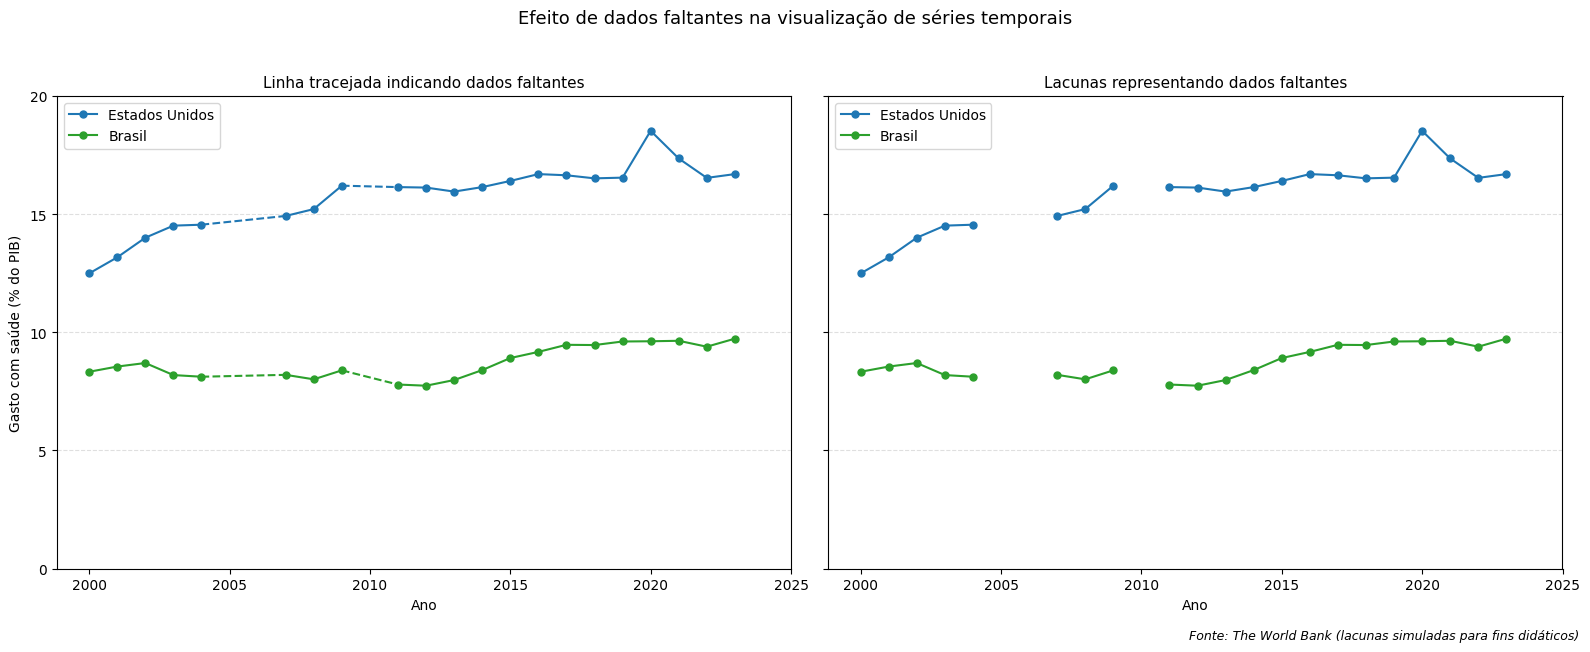

In [8]:
import numpy as np
import matplotlib.pyplot as plt

# --- Simulando dados faltantes entre 2004-2007 e 2009-2011 ---
anos_faltantes = [2005, 2006, 2010]  # anos "sem dado" entre os extremos conhecidos

def aplica_faltantes(df, anos_faltantes):
    df = df.copy()
    df.loc[df["ano"].isin(anos_faltantes), "valor"] = np.nan
    return df

eua_falt = aplica_faltantes(eua, anos_faltantes)
brasil_falt = aplica_faltantes(brasil, anos_faltantes)

def segmentos_faltantes(df):
    """Identifica, para cada bloco de NaN, o ponto conhecido imediatamente
    antes e depois da lacuna -- usados para desenhar a linha tracejada."""
    valores = df["valor"].values
    anos = df["ano"].values
    is_nan = np.isnan(valores)
    segmentos = []
    i, n = 0, len(df)
    while i < n:
        if is_nan[i]:
            antes_idx = i - 1
            j = i
            while j < n and is_nan[j]:
                j += 1
            depois_idx = j
            if antes_idx >= 0 and depois_idx < n:
                segmentos.append((anos[antes_idx], valores[antes_idx],
                                   anos[depois_idx], valores[depois_idx]))
            i = j
        else:
            i += 1
    return segmentos

cores = {"Estados Unidos": "#1f77b4", "Brasil": "#2ca02c"}
series = [("Estados Unidos", eua_falt), ("Brasil", brasil_falt)]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

# --- Painel 1: linha tracejada indicando dados faltantes ---
for nome, df in series:
    cor = cores[nome]
    ax1.plot(df["ano"], df["valor"], marker="o", markersize=5, label=nome, color=cor)  # NaN já quebra a linha
    for ano_a, val_a, ano_d, val_d in segmentos_faltantes(df):
        ax1.plot([ano_a, ano_d], [val_a, val_d], color=cor,
                  linestyle="--", linewidth=1.5)

ax1.set_title("Linha tracejada indicando dados faltantes", fontsize=11)
ax1.set_xlabel("Ano")
ax1.set_ylabel("Gasto com saúde (% do PIB)")
ax1.set_xticks(np.arange(2000, 2026, 5))
ax1.legend()
ax1.grid(axis="y", linestyle="--", alpha=0.4)

# --- Painel 2: lacunas representando dados faltantes ---
for nome, df in series:
    ax2.plot(df["ano"], df["valor"], marker="o", markersize=5,label=nome, color=cores[nome])

ax2.set_title("Lacunas representando dados faltantes", fontsize=11)
ax2.set_xlabel("Ano")
ax2.set_xticks(np.arange(2000, 2026, 5))
ax2.legend()
ax2.grid(axis="y", linestyle="--", alpha=0.4)

ax1.set_yticks(np.arange(0, df_pib["valor"].max() + 5, 5))

fig.suptitle("Efeito de dados faltantes na visualização de séries temporais",
             fontsize=13, y=1.03)
fig.text(0.99, -0.02,
          "Fonte: The World Bank (lacunas simuladas para fins didáticos)",
          ha="right", fontsize=9, style="italic")

plt.tight_layout()
plt.show()

### Evite gráficos de linhas com dois eixos

Você pode sentir vontade de adicionar outro eixo vertical ao seu gráfico de linhas ao comparar variações em duas ou mais séries com unidades diferentes. Resista a essa tentação. Considere este gráfico de linhas de eixo duplo que mostra a parcela da renda destinada a despesas com moradia no eixo esquerdo e a taxa trimestral de desemprego no eixo direito, nos Estados Unidos, entre 2000 e 2018. Não fica imediatamente claro que a linha azul representa a taxa de desemprego (associada ao eixo direito) e a linha amarela representa o endividamento com moradia (plotada no eixo esquerdo). O objetivo deste gráfico é demonstrar que o cenário econômico para os consumidores em 2017 e 2018 era bastante favorável, com baixas taxas de desemprego e baixo endividamento habitacional.

Mas há três problemas em representar os dados dessa forma.

Primeiro, eles costumam ser difíceis de ler. Você sabia intuitivamente quais linhas correspondiam a quais eixos? Eu não sabia. Mesmo que os rótulos e os eixos tivessem cores que combinassem com as linhas (algo que muitos gráficos de eixo duplo não apresentam), é difícil identificar padrões nos dados. Eles exigem um esforço adicional do leitor, especialmente quando a rotulagem não é óbvia.

Em segundo lugar, as linhas de grade podem não coincidir. Observe como as linhas de grade horizontais deste gráfico estão associadas ao eixo esquerdo, o que deixa os números do eixo direito "flutuando" no espaço. No ponto de cruzamento em 2009, é difícil perceber que o valor da taxa de desemprego (a linha azul) está logo abaixo de 9%.

Em terceiro lugar — e o mais importante —, o ponto onde as linhas se cruzam torna-se um ponto focal, ainda que possa não ter nenhum significado real. Neste gráfico, o olhar é atraído para o centro, onde as duas linhas se cruzam, pois é ali que acontece o aspecto mais interessante. No entanto, não há nada de especial em 2009; o fato de elas terem se cruzado naquele momento é mera coincidência. A mensagem que o gráfico pretende transmitir é o quanto o cenário econômico melhorou desde a recessão de 2007-2009, mas não é isso que chama a atenção.

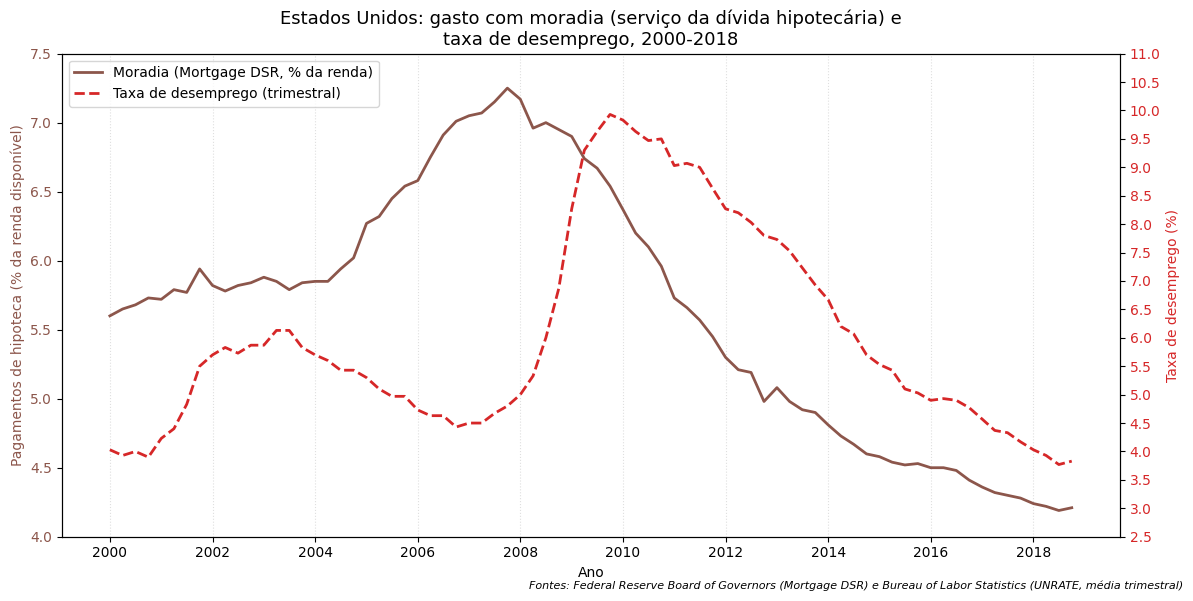

In [9]:
df = pd.read_csv("../Data/moradia_desemprego_EUA_2000-2018.csv", parse_dates=["data"])

fig, ax1 = plt.subplots(figsize=(12, 6))

cor_moradia = "#8c564b"
cor_desemprego = "#d62728"

ax1.plot(df["data"], df["moradia_pct_renda"], color=cor_moradia, linewidth=2,
         label="Moradia (Mortgage DSR, % da renda)")
ax1.set_ylabel("Pagamentos de hipoteca (% da renda disponível)", color=cor_moradia)
ax1.tick_params(axis="y", labelcolor=cor_moradia)
ax1.set_yticks(np.arange(4, 8, 0.5))
ax1.set_xlabel("Ano")

ax2 = ax1.twinx()
ax2.plot(df["data"], df["desemprego_pct"], color=cor_desemprego, linewidth=2,
         linestyle="--", label="Taxa de desemprego (trimestral)")
ax2.set_ylabel("Taxa de desemprego (%)", color=cor_desemprego)
ax2.tick_params(axis="y", labelcolor=cor_desemprego)
ax2.set_yticks(np.arange(2.5, 11.5, 0.5))
ax1.xaxis.set_major_locator(mdates.YearLocator(2))
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

ax1.set_title(
    "Estados Unidos: gasto com moradia (serviço da dívida hipotecária) e\n"
    "taxa de desemprego, 2000-2018",
    fontsize=13
)

linhas1, rotulos1 = ax1.get_legend_handles_labels()
linhas2, rotulos2 = ax2.get_legend_handles_labels()
ax1.legend(linhas1 + linhas2, rotulos1 + rotulos2, loc="upper left")

ax1.grid(axis="x", linestyle=":", alpha=0.4)

fig.text(0.99, 0.01,
         "Fontes: Federal Reserve Board of Governors (Mortgage DSR) e Bureau of Labor Statistics (UNRATE, média trimestral)",
         ha="right", fontsize=8, style="italic")

plt.tight_layout()
plt.show()

O eixo vertical de um gráfico de linhas não precisa começar em zero; portanto, este gráfico — com o eixo esquerdo começando em 9,5% e o eixo direito começando em 2,5% — é uma maneira perfeitamente razoável de representar as duas séries. Seguindo essa lógica, poderíamos alterar arbitrariamente as dimensões de cada eixo para fazer com que as linhas se cruzassem onde bem entendêssemos. E é aí que reside o problema dos gráficos de linhas com dois eixos: quem cria o gráfico pode induzir os leitores ao erro deliberadamente quanto à relação entre as séries.

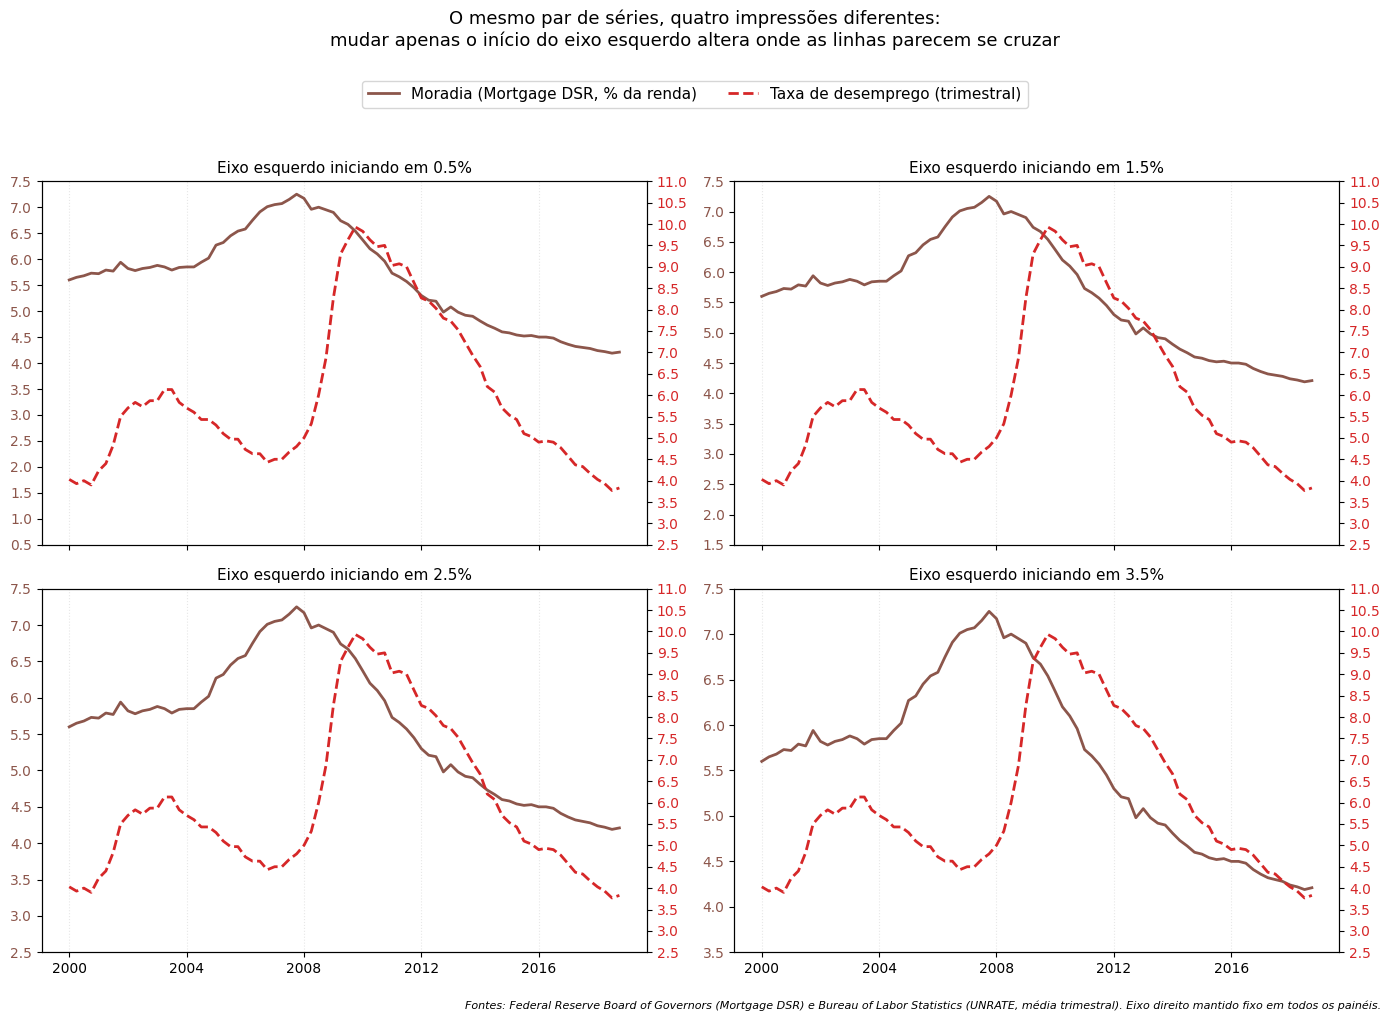

In [10]:

cor_moradia = "#8c564b"
cor_desemprego = "#d62728"

# Quatro pontos de partida diferentes para o eixo esquerdo (moradia)
inicios_eixo_esquerdo = [0.5, 1.5, 2.5, 3.5]

# O eixo direito (desemprego) permanece FIXO em todos os painéis --
# só o eixo esquerdo é manipulado, para isolar o efeito.
yticks_direita = np.arange(2.5, 10.5, 1.0)

fig, axs = plt.subplots(2, 2, figsize=(14, 9), sharex=True)

for ax1, inicio in zip(axs.flat, inicios_eixo_esquerdo):
    ax2 = ax1.twinx()

    ax1.plot(df["data"], df["moradia_pct_renda"], color=cor_moradia, linewidth=2,
              label="Moradia (Mortgage DSR, % da renda)")
    ax2.plot(df["data"], df["desemprego_pct"], color=cor_desemprego, linewidth=2,
              linestyle="--", label="Taxa de desemprego (trimestral)")

    yticks_esquerda = np.arange(inicio, 8, 0.5)
    ax1.set_yticks(yticks_esquerda)
    ax1.set_ylim(yticks_esquerda[0], yticks_esquerda[-1])

    ax2.set_yticks(yticks_direita)
    ax2.set_ylim(yticks_direita[0], yticks_direita[-1])

    ax1.tick_params(axis="y", labelcolor=cor_moradia)
    ax2.tick_params(axis="y", labelcolor=cor_desemprego)
    ax2.set_yticks(np.arange(2.5, 11.5, 0.5))

    ax1.set_title(f"Eixo esquerdo iniciando em {inicio}%", fontsize=11)
    ax1.xaxis.set_major_locator(mdates.YearLocator(4))
    ax1.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax1.grid(axis="x", linestyle=":", alpha=0.3)

handles = [plt.Line2D([0], [0], color=cor_moradia, lw=2, label="Moradia (Mortgage DSR, % da renda)"),
           plt.Line2D([0], [0], color=cor_desemprego, lw=2, ls="--", label="Taxa de desemprego (trimestral)")]
fig.legend(handles=handles, loc="upper center", ncol=2, bbox_to_anchor=(0.5, 1.02), fontsize=11)

fig.suptitle(
    "O mesmo par de séries, quatro impressões diferentes:\n"
    "mudar apenas o início do eixo esquerdo altera onde as linhas parecem se cruzar",
    fontsize=13, y=1.09
)

fig.text(0.99, -0.02,
         "Fontes: Federal Reserve Board of Governors (Mortgage DSR) e Bureau of Labor Statistics (UNRATE, média trimestral). "
         "Eixo direito mantido fixo em todos os painéis.",
         ha="right", fontsize=8, style="italic")

plt.tight_layout()
plt.show()

Cada um desses quatro gráficos apresenta formas razoáveis ​​de definir os eixos verticais e, ao manipular essas faixas, posso fazer com que as séries pareçam: (a) muito próximas por alguns anos em torno de 2010 e 2012; (b) cruzar-se no meio e no final; (c) interceptar-se por volta de 2003 e novamente alguns anos depois; e (d) estar fortemente relacionadas na primeira metade do período, mas depois divergir.

Ao escolher arbitrariamente a escala dos eixos, podemos fazer com que diferentes séries de dados pareçam tão correlacionadas quanto quisermos. Em seu site, *Spurious Correlations*, Tyler Vigen apresenta diversos tipos de gráficos de eixo duplo nos quais escalas arbitrárias no eixo vertical criam correlações equivocadas — e divertidas.

Dificuldades semelhantes, embora em grau ligeiramente diferente, ocorrem em gráficos de eixo duplo que combinam diferentes tipos de representação gráfica. Na página seguinte, você pode ver o mesmo gráfico da taxa de desemprego e da dívida habitacional, agora com a taxa de desemprego representada como um gráfico de área. O eixo da direita começa em zero para que as linhas de grade de ambos os lados coincidam, mas ainda não fica imediatamente claro qual variável corresponde a qual eixo. E, embora fique mais evidente que duas tendências distintas estão sendo visualizadas, persistem as mesmas armadilhas de percepção, levando os leitores a enxergar correlações que talvez não existam de fato.

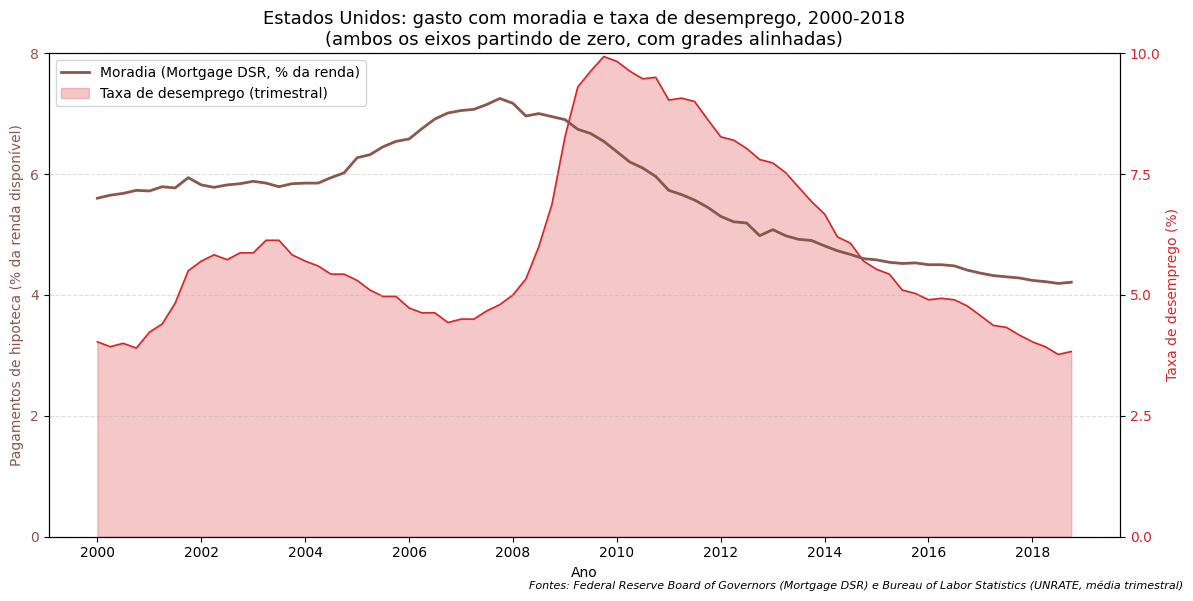

In [11]:

cor_moradia = "#8c564b"
cor_desemprego = "#d62728"

fig, ax1 = plt.subplots(figsize=(12, 6))
ax2 = ax1.twinx()

# --- Eixo direito: desemprego como área, partindo de zero ---
ax2.fill_between(df["data"], 0, df["desemprego_pct"],
                  color=cor_desemprego, alpha=0.25, label="Taxa de desemprego (trimestral)")
ax2.plot(df["data"], df["desemprego_pct"], color=cor_desemprego, linewidth=1.2)

# --- Eixo esquerdo: moradia como linha, também partindo de zero ---
ax1.plot(df["data"], df["moradia_pct_renda"], color=cor_moradia, linewidth=2,
          label="Moradia (Mortgage DSR, % da renda)")

# Ambos os eixos começam em 0 e usam o mesmo número de marcações (5),
# igualmente espaçadas -- assim as linhas de grade coincidem nos dois lados.
ax1.set_ylim(0, 8)
ax1.set_yticks(np.linspace(0, 8, 5))   # 0, 2, 4, 6, 8

ax2.set_ylim(0, 10)
ax2.set_yticks(np.linspace(0, 10, 5))  # 0, 2.5, 5, 7.5, 10

ax1.tick_params(axis="y", labelcolor=cor_moradia)
ax2.tick_params(axis="y", labelcolor=cor_desemprego)
ax1.set_ylabel("Pagamentos de hipoteca (% da renda disponível)", color=cor_moradia)
ax2.set_ylabel("Taxa de desemprego (%)", color=cor_desemprego)
ax1.set_xlabel("Ano")

# Grade única (a partir do eixo esquerdo) -- como os dois eixos têm a
# mesma proporção a partir de zero, ela serve igualmente para o direito.
ax1.grid(axis="y", linestyle="--", alpha=0.4)
ax1.set_axisbelow(True)
ax2.set_zorder(ax1.get_zorder() - 1)  # área do desemprego atrás da linha de moradia
ax1.patch.set_visible(False)

ax1.xaxis.set_major_locator(mdates.YearLocator(2))
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

ax1.set_title(
    "Estados Unidos: gasto com moradia e taxa de desemprego, 2000-2018\n"
    "(ambos os eixos partindo de zero, com grades alinhadas)",
    fontsize=13
)

handles = [plt.Line2D([0], [0], color=cor_moradia, lw=2, label="Moradia (Mortgage DSR, % da renda)"),
           plt.Rectangle((0, 0), 1, 1, color=cor_desemprego, alpha=0.25, label="Taxa de desemprego (trimestral)")]
ax1.legend(handles=handles, loc="upper left")

fig.text(0.99, 0.01,
         "Fontes: Federal Reserve Board of Governors (Mortgage DSR) e Bureau of Labor Statistics (UNRATE, média trimestral)",
         ha="right", fontsize=8, style="italic")

plt.tight_layout()
plt.show()

Existem algumas soluções para o desafio dos gráficos de eixo duplo.

Primeiro, tente colocar os gráficos lado a lado. Lembre-se de que nem tudo precisa estar concentrado em um único gráfico; podemos dividir as informações e adotar uma abordagem de múltiplos gráficos (ou *small multiples*). Embora o ideal seja que gráficos lado a lado compartilhem o mesmo eixo vertical para facilitar a comparação, já constatamos que isso não é viável neste caso; portanto, separá-los e utilizar intervalos de eixo diferentes pode funcionar.

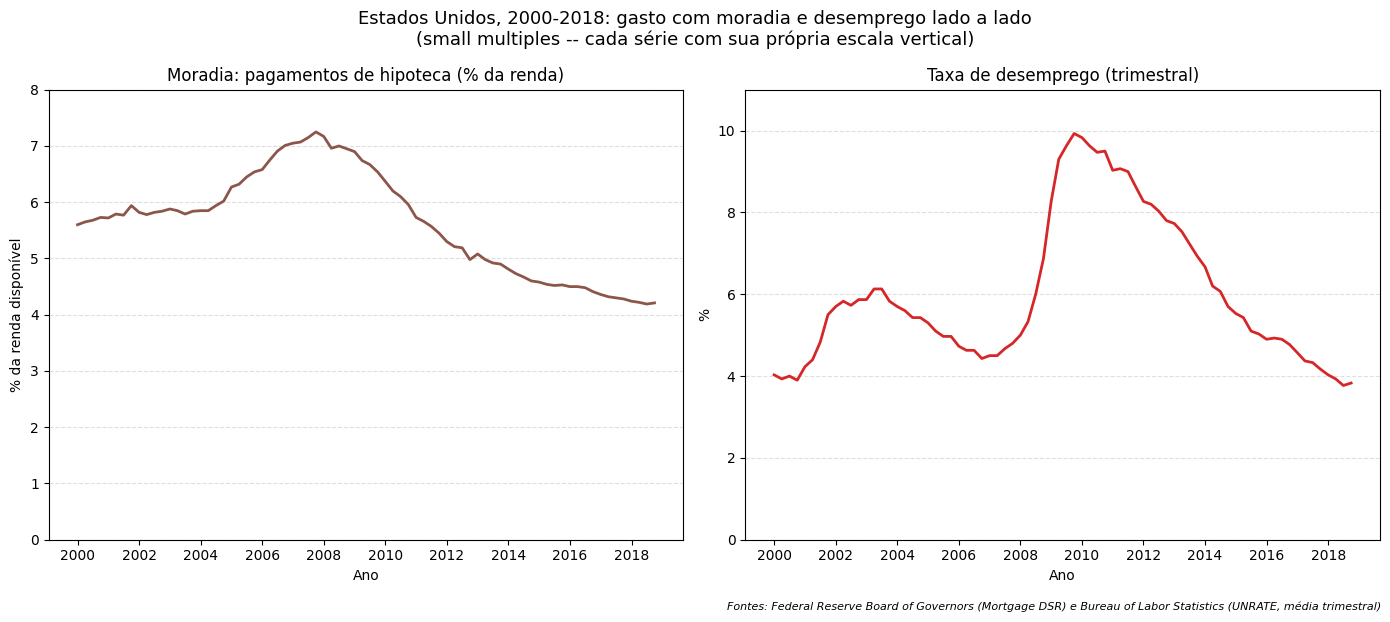

In [12]:

cor_moradia = "#8c564b"
cor_desemprego = "#d62728"

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6), sharex=True)

# --- Painel 1: moradia, com sua própria escala ---
ax1.plot(df["data"], df["moradia_pct_renda"], color=cor_moradia, linewidth=2)
ax1.set_title("Moradia: pagamentos de hipoteca (% da renda)", fontsize=12)
ax1.set_ylabel("% da renda disponível")
ax1.set_xlabel("Ano")
ax1.set_ylim(0, 8)
ax1.grid(axis="y", linestyle="--", alpha=0.4)

# --- Painel 2: desemprego, com sua própria escala ---
ax2.plot(df["data"], df["desemprego_pct"], color=cor_desemprego, linewidth=2)
ax2.set_title("Taxa de desemprego (trimestral)", fontsize=12)
ax2.set_ylabel("%")
ax2.set_xlabel("Ano")
ax2.set_ylim(0, 11)
ax2.grid(axis="y", linestyle="--", alpha=0.4)

# Eixo x compartilhado -- mesmos anos nos dois painéis
for ax in (ax1, ax2):
    ax.xaxis.set_major_locator(mdates.YearLocator(2))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

fig.suptitle(
    "Estados Unidos, 2000-2018: gasto com moradia e desemprego lado a lado\n"
    "(small multiples -- cada série com sua própria escala vertical)",
    fontsize=13
)

fig.text(0.99, -0.02,
         "Fontes: Federal Reserve Board of Governors (Mortgage DSR) e Bureau of Labor Statistics (UNRATE, média trimestral)",
         ha="right", fontsize=8, style="italic")

plt.tight_layout()
plt.show()

Se for importante marcar um ponto específico no eixo horizontal, você também pode dispor os dois elementos verticalmente e traçar uma linha que atravesse ambos. Isso alterará a orientação do gráfico final, mas é uma maneira mais fácil de identificar um valor ou ano específico.

/tmp/ipykernel_16886/397223616.py:52: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


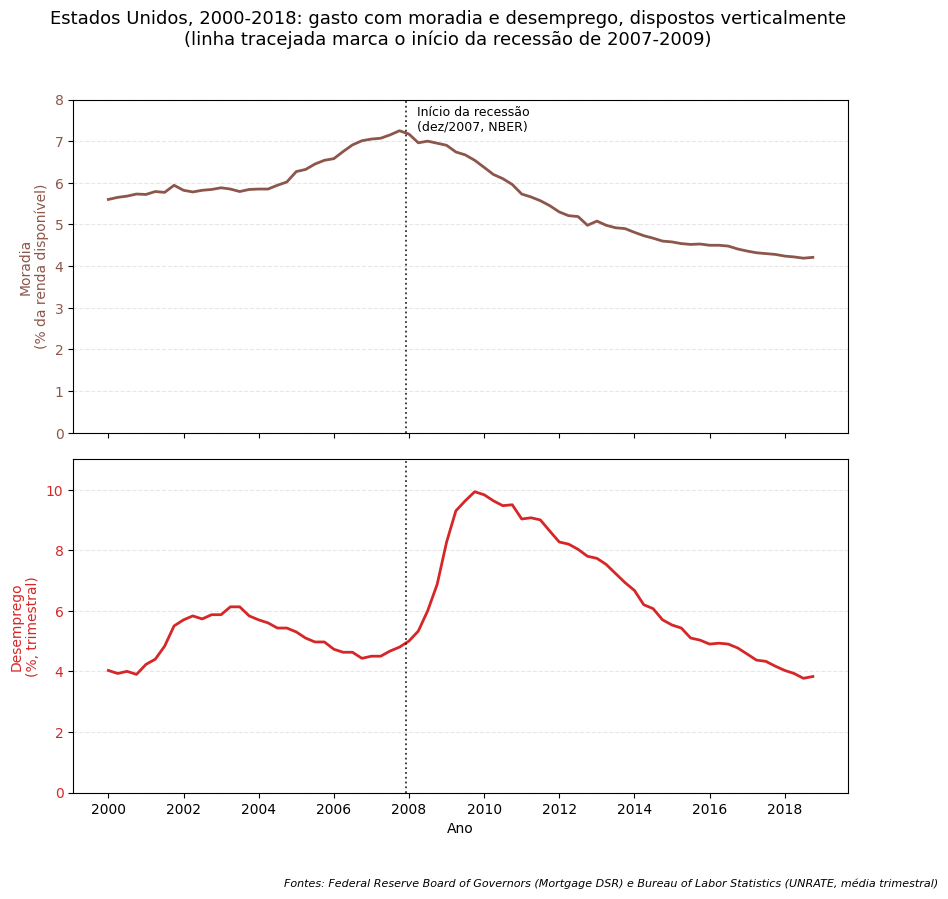

In [13]:

cor_moradia = "#8c564b"
cor_desemprego = "#d62728"

# Ponto que queremos destacar: início oficial da recessão de 2007-2009 (NBER)
data_destaque = pd.Timestamp("2007-12-01")

fig, (ax1, ax2) = plt.subplots(
    2, 1, figsize=(10, 9), sharex=True,
    gridspec_kw={"hspace": 0.08}
)

# --- Painel superior: moradia ---
ax1.plot(df["data"], df["moradia_pct_renda"], color=cor_moradia, linewidth=2)
ax1.set_ylabel("Moradia\n(% da renda disponível)", color=cor_moradia)
ax1.tick_params(axis="y", labelcolor=cor_moradia)
ax1.set_ylim(0, 8)
ax1.grid(axis="y", linestyle="--", alpha=0.3)

# --- Painel inferior: desemprego ---
ax2.plot(df["data"], df["desemprego_pct"], color=cor_desemprego, linewidth=2)
ax2.set_ylabel("Desemprego\n(%, trimestral)", color=cor_desemprego)
ax2.tick_params(axis="y", labelcolor=cor_desemprego)
ax2.set_ylim(0, 11)
ax2.grid(axis="y", linestyle="--", alpha=0.3)
ax2.set_xlabel("Ano")

ax2.xaxis.set_major_locator(mdates.YearLocator(2))
ax2.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

# --- Linha vertical atravessando os dois painéis, marcando o mesmo ponto no tempo ---
for ax in (ax1, ax2):
    ax.axvline(data_destaque, color="black", linestyle=":", linewidth=1.3, alpha=0.8)

# Rótulo do ponto destacado, colocado apenas no painel de cima
ax1.annotate(
    "Início da recessão\n(dez/2007, NBER)",
    xy=(data_destaque, ax1.get_ylim()[1]),
    xytext=(8, -4), textcoords="offset points",
    ha="left", va="top", fontsize=9, color="black"
)

fig.suptitle(
    "Estados Unidos, 2000-2018: gasto com moradia e desemprego, dispostos verticalmente\n"
    "(linha tracejada marca o início da recessão de 2007-2009)",
    fontsize=13
)

fig.text(0.99, 0.005,
         "Fontes: Federal Reserve Board of Governors (Mortgage DSR) e Bureau of Labor Statistics (UNRATE, média trimestral)",
         ha="right", fontsize=8, style="italic")

plt.tight_layout()
plt.show()

Em segundo lugar, podemos calcular um índice ou a variação percentual em relação a um determinado valor ou ano (veja a página 148). Dessa forma, o leitor consegue visualizar a evolução de ambas as séries ao longo do tempo e compará-las com base na mesma métrica. Nos dados que estamos analisando aqui, calculamos a diferença entre cada ano e o ano de 2000 — o primeiro do período —, obtendo assim a variação em pontos percentuais. A contrapartida evidente, nesse caso, é que deixamos de apresentar os dados em seus valores absolutos (níveis) para apresentar a variação.

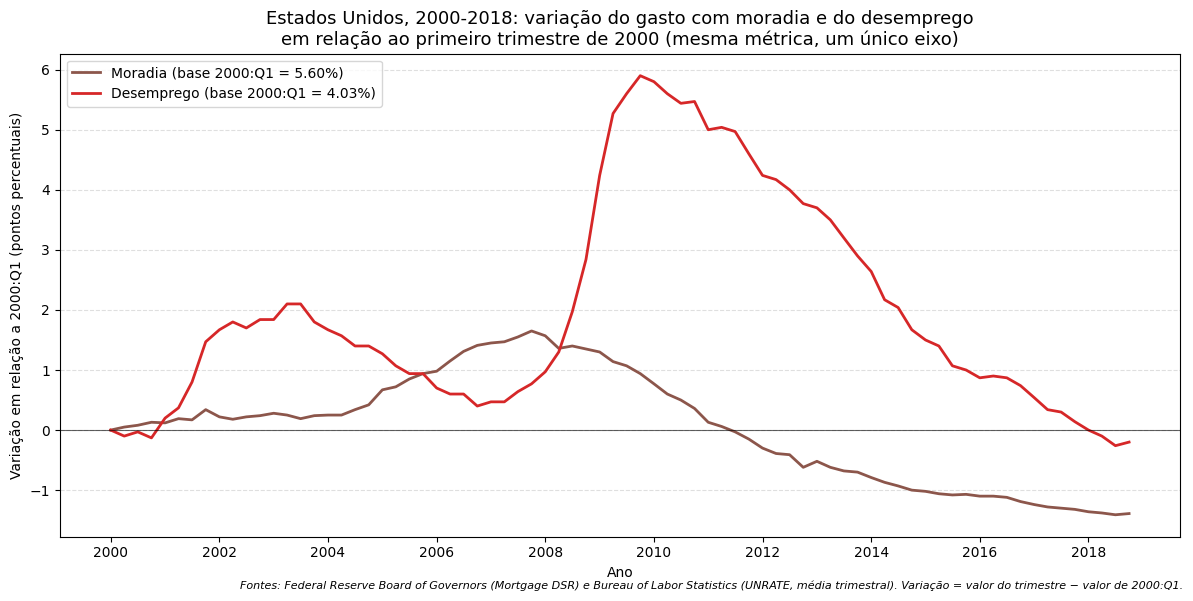

In [14]:
cor_moradia = "#8c564b"
cor_desemprego = "#d62728"

# Valores de referência: primeiro trimestre da série (2000:Q1)
base_moradia = df.loc[0, "moradia_pct_renda"]
base_desemprego = df.loc[0, "desemprego_pct"]

# Variação em relação a 2000, em pontos percentuais (p.p.)
df["moradia_var_pp"] = df["moradia_pct_renda"] - base_moradia
df["desemprego_var_pp"] = df["desemprego_pct"] - base_desemprego

fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(df["data"], df["moradia_var_pp"], color=cor_moradia, linewidth=2,
        label=f"Moradia (base 2000:Q1 = {base_moradia:.2f}%)")
ax.plot(df["data"], df["desemprego_var_pp"], color=cor_desemprego, linewidth=2,
        label=f"Desemprego (base 2000:Q1 = {base_desemprego:.2f}%)")

ax.axhline(0, color="black", linewidth=0.8, alpha=0.6)  # linha de base (variação zero)

ax.set_ylabel("Variação em relação a 2000:Q1 (pontos percentuais)")
ax.set_xlabel("Ano")
ax.xaxis.set_major_locator(mdates.YearLocator(2))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.grid(axis="y", linestyle="--", alpha=0.4)
ax.legend(loc="upper left")

ax.set_title(
    "Estados Unidos, 2000-2018: variação do gasto com moradia e do desemprego\n"
    "em relação ao primeiro trimestre de 2000 (mesma métrica, um único eixo)",
    fontsize=13
)

fig.text(0.99, 0.01,
         "Fontes: Federal Reserve Board of Governors (Mortgage DSR) e Bureau of Labor Statistics (UNRATE, média trimestral). "
         "Variação = valor do trimestre − valor de 2000:Q1.",
         ha="right", fontsize=8, style="italic")

plt.tight_layout()
plt.show()

Em terceiro lugar, experimente um tipo de gráfico diferente. Se for importante mostrar as mudanças nas associações entre as duas séries, tente usar um gráfico de dispersão com pontos conectados. Esse tipo de gráfico — que conta com uma seção própria ao final deste capítulo — assemelha-se a um gráfico de dispersão convencional com eixos horizontal e vertical, mas cada ponto representa uma unidade de tempo distinta, como um trimestre ou um ano. Como você pode ver na página seguinte, fica mais fácil visualizar como a relação entre essas duas métricas evoluiu ao longo do tempo. Observe também como adicionei mais rótulos e anotações (além de cores variadas) para ajudar o leitor a interpretar a visualização.

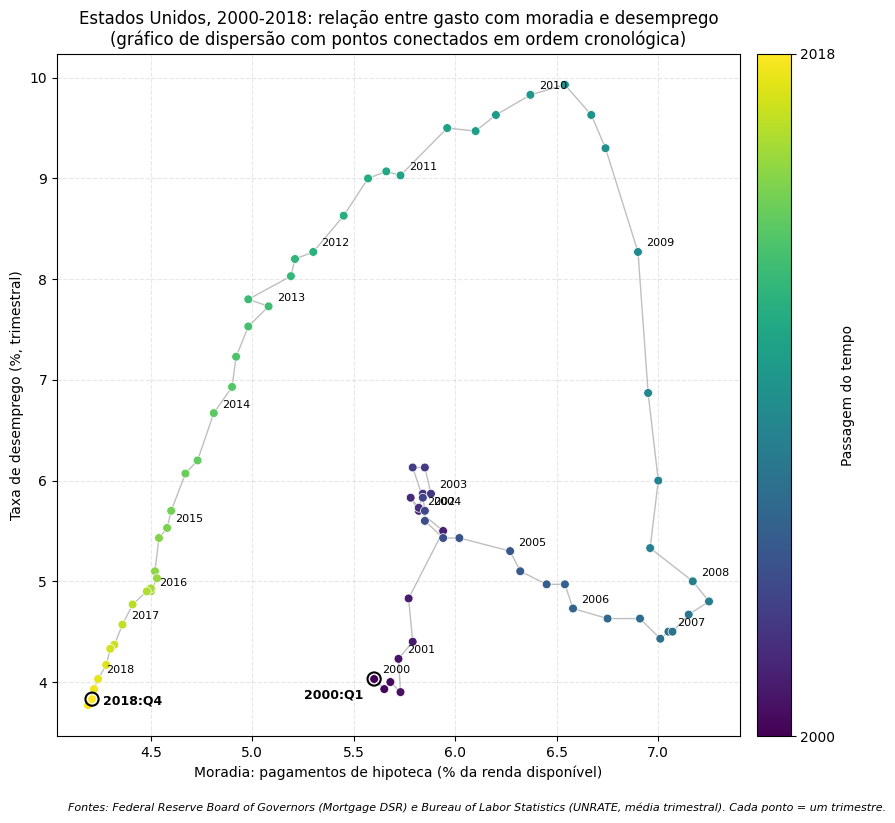

In [15]:

fig, ax = plt.subplots(figsize=(9, 8))

x = df["moradia_pct_renda"].values
y = df["desemprego_pct"].values

# Linha fina conectando os trimestres na ordem cronológica
ax.plot(x, y, color="gray", linewidth=1, alpha=0.5, zorder=1)

# Pontos coloridos por tempo (do mais antigo/escuro ao mais recente/claro)
sc = ax.scatter(x, y, c=np.arange(len(df)), cmap="viridis", s=40,
                 zorder=2, edgecolor="white", linewidth=0.5)

# Rótulos de ano apenas no 1º trimestre de cada ano, para não poluir o gráfico
marcos = df[df["trimestre"] == 1]
for _, row in marcos.iterrows():
    ax.annotate(str(row["ano"]),
                (row["moradia_pct_renda"], row["desemprego_pct"]),
                textcoords="offset points", xytext=(6, 4), fontsize=8)

# Destaque especial de início e fim
ax.scatter(x[0], y[0], s=90, facecolor="none", edgecolor="black", linewidth=1.5, zorder=3)
ax.annotate("2000:Q1", (x[0], y[0]), textcoords="offset points", xytext=(-8, -14),
            fontsize=9, fontweight="bold", ha="right")
ax.scatter(x[-1], y[-1], s=90, facecolor="none", edgecolor="black", linewidth=1.5, zorder=3)
ax.annotate("2018:Q4", (x[-1], y[-1]), textcoords="offset points", xytext=(8, -4),
            fontsize=9, fontweight="bold")

cbar = fig.colorbar(sc, ax=ax, pad=0.02)
cbar.set_ticks([0, len(df) - 1])
cbar.set_ticklabels(["2000", "2018"])
cbar.set_label("Passagem do tempo")

ax.set_xlabel("Moradia: pagamentos de hipoteca (% da renda disponível)")
ax.set_ylabel("Taxa de desemprego (%, trimestral)")
ax.set_title(
    "Estados Unidos, 2000-2018: relação entre gasto com moradia e desemprego\n"
    "(gráfico de dispersão com pontos conectados em ordem cronológica)",
    fontsize=12
)
ax.grid(linestyle="--", alpha=0.3)

fig.text(0.99, -0.02,
         "Fontes: Federal Reserve Board of Governors (Mortgage DSR) e Bureau of Labor Statistics (UNRATE, média trimestral). "
         "Cada ponto = um trimestre.",
         ha="right", fontsize=8, style="italic")

plt.tight_layout()
plt.show()

Uma possível exceção à regra de "não usar gráficos de eixo duplo" ocorre quando se apresenta a conversão de uma única métrica — por exemplo, temperaturas em Fahrenheit e Celsius. Nesses casos, não se busca acompanhar duas variáveis ​​distintas, mas sim demonstrar como uma delas corresponde diretamente à outra. Nessas situações, os problemas habituais associados a esse tipo de gráfico não se aplicam.

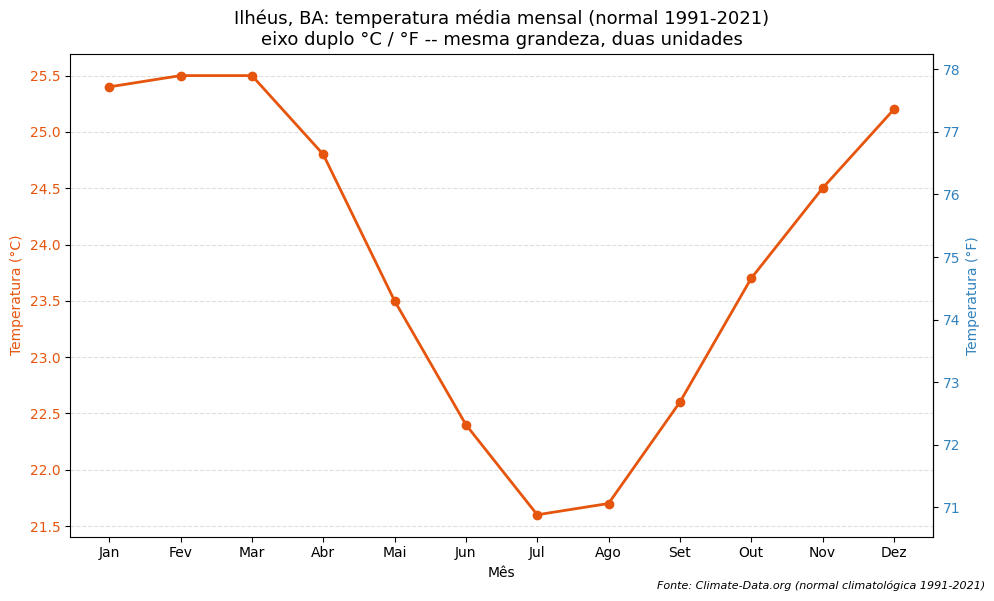

In [16]:

meses = ["Jan", "Fev", "Mar", "Abr", "Mai", "Jun",
         "Jul", "Ago", "Set", "Out", "Nov", "Dez"]

# Temperatura média mensal em Ilhéus, BA (normal climatológica 1991-2021)
# Fonte: Climate-Data.org
temp_c = np.array([25.4, 25.5, 25.5, 24.8, 23.5, 22.4,
                    21.6, 21.7, 22.6, 23.7, 24.5, 25.2])

def c_para_f(c):
    return c * 9 / 5 + 32

fig, ax1 = plt.subplots(figsize=(10, 6))

ax1.plot(meses, temp_c, color="#e6550d", marker="o", linewidth=2)
ax1.set_ylabel("Temperatura (°C)", color="#e6550d")
ax1.tick_params(axis="y", labelcolor="#e6550d")
ax1.set_xlabel("Mês")
ax1.grid(axis="y", linestyle="--", alpha=0.4)

# Eixo direito: NÃO é uma segunda variável, é a MESMA temperatura em Fahrenheit.
# secondary_yaxis aplica a função de conversão diretamente sobre o eixo esquerdo,
# então os dois eixos ficam matematicamente amarrados -- não há como "escolher"
# limites diferentes para induzir uma leitura equivocada.
ax2 = ax1.secondary_yaxis("right", functions=(c_para_f, lambda f: (f - 32) * 5 / 9))
ax2.set_ylabel("Temperatura (°F)", color="#3182bd")
ax2.tick_params(axis="y", labelcolor="#3182bd")

ax1.set_title(
    "Ilhéus, BA: temperatura média mensal (normal 1991-2021)\n"
    "eixo duplo °C / °F -- mesma grandeza, duas unidades",
    fontsize=13
)

fig.text(0.99, 0.01, "Fonte: Climate-Data.org (normal climatológica 1991-2021)",
          ha="right", fontsize=8, style="italic")

plt.tight_layout()
plt.show()